[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 09 Linear Regression
- Univariate Regression
- Model Selection

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## Weastern US Bruned Area

In [5]:
df = pd.read_csv('WUS_afab.csv')
df

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


### Considering only VPD #vapor pressure data
- define predictor and predictant

In [6]:
x =  df['vpd_hPa'].to_numpy() #VPD
y = df['afab_km2'].to_numpy()

n = len(y) # # of sample size

- check the data realtionshp

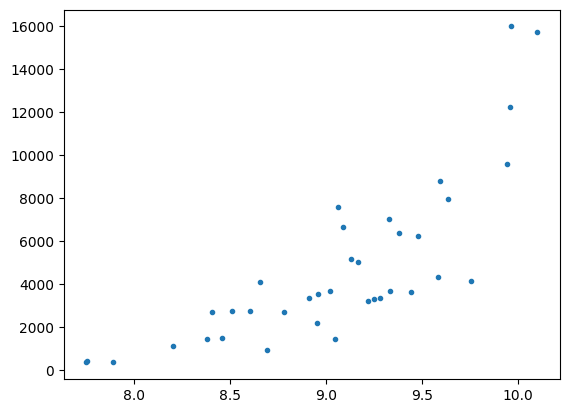

In [7]:
plt.plot(x,y,'.')

- let's try linear fit $y = \beta_0+\beta_1\times X$
- using statsmodels #model

In [8]:
import statsmodels.api as sm

In [9]:
y = df['afab_km2']                          # response array
X = sm.add_constant(df['vpd_hPa'])## add a constant for beta0
X

,const,vpd_hPa
0,1.0,7.753
1,1.0,8.511
2,1.0,7.750
3,1.0,8.459
4,1.0,9.063
5,1.0,8.201
6,1.0,7.888
7,1.0,8.912
8,1.0,8.406
9,1.0,8.778


In [10]:
# do a fitting
m1_lin = sm.OLS(y, X).fit()
m1_lin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     58.92
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           5.24e-09
Time:                        17:47:01   Log-Likelihood:                -339.09
No. Observations:                  37   AIC:                             682.2
Df Residuals:                      35   BIC:                             685.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.057e+04   5914.718     -6.859      0.000   -5.26e+04   -2.86e+04
vpd_hPa     5008.8019    652.512      7.676      0.000    3684.132    6333.472
==============================================================================
Omnibus:                        5.280   Durbin-Watson:                   1.834
Prob(Omnibus):                  0.071   Jarque-Bera (JB):                3.823
Skew:                           0.679   Prob(JB):                        0.148
Kurtosis:                       3.797   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- check fitted values

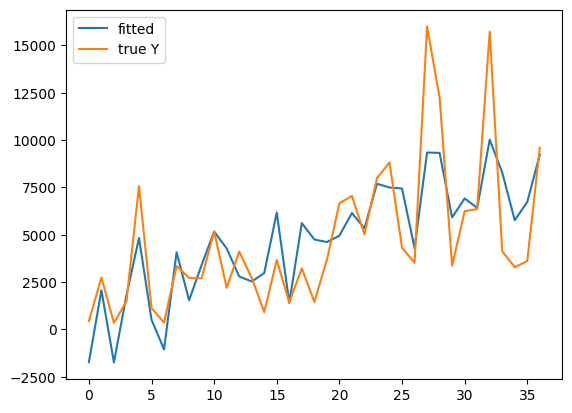

In [15]:
plt.plot(m1_lin.fittedvalues, label='fitted') #fitted in blue, original in green
plt.plot(y, label = 'true Y')
plt.legend()

- check residual

In [16]:
import statsmodels.tsa.stattools as stattools
stattools.acf(m1_lin.resid,nlags=1)[1]

np.float64(0.07052958676311427)

- lets try fit $log(y) = \beta_0+\beta_1\times X$

In [17]:
m1_loglinear = sm.OLS(np.log(y), X).fit() #log y as a function of x
m1_loglinear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     132.8
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.82e-13
Time:                        17:51:20   Log-Likelihood:                -20.790
No. Observations:                  37   AIC:                             45.58
Df Residuals:                      35   BIC:                             48.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3752      1.086     -4.029      0.000      -6.580      -2.171
vpd_hPa        1.3807      0.120     11.525      0.000       1.138       1.624
==============================================================================
Omnibus:                        0.668   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.716   Jarque-Bera (JB):                0.742
Skew:                          -0.163   Prob(JB):                        0.690
Kurtosis:                       2.388   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
stattools.acf(m1_loglinear.resid,nlags=1)[1]

np.float64(0.06867053821785953)

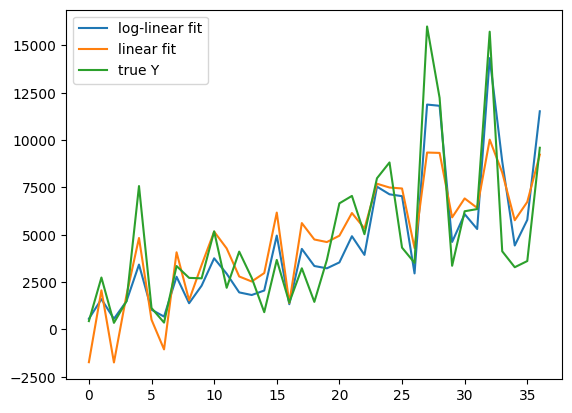

In [21]:
plt.plot(np.exp(m1_loglinear.fittedvalues), label='log-linear fit')
plt.plot(m1_lin.fittedvalues, label='linear fit')
plt.plot(y, label='true Y')
plt.legend()

- plot the fitted line with a given VPD

In [22]:
xx = np.linspace(x.min(), x.max(), 200)
xx_vpd = sm.add_constant(xx)

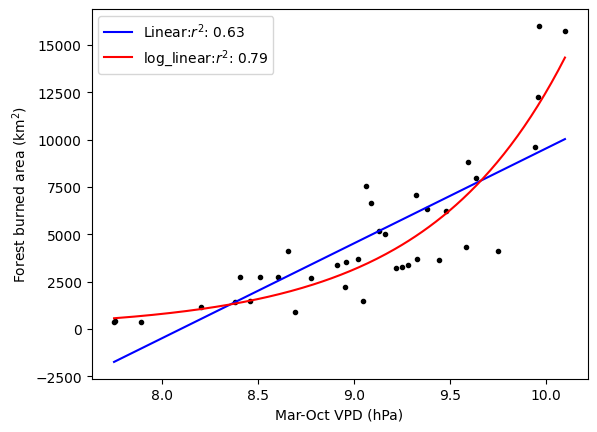

In [23]:
plt.plot(x,y,'k.')

### linear:
y_lin_fit = m1_lin.predict(xx_vpd)
plt.plot(xx,y_lin_fit,'b-',label=f"Linear:$r^2$: {m1_lin.rsquared:.2f}")
### poisson

logy_fit = m1_loglinear.predict(xx_vpd)   # fitted ln(AFAB)
y_fit    = np.exp(logy_fit)                # fitted AFAB (median), km²
plt.plot(xx,y_fit,'r-',label=f"log_linear:$r^2$: {m1_loglinear.rsquared:.2f}")
plt.legend()
plt.xlabel('Mar-Oct VPD (hPa)')
plt.ylabel('Forest burned area (km$^2$)')
plt.savefig('ols_afab_vpd.png', dpi=200)

### considering both VPD and wind

In [26]:
df

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


In [28]:
## need to modify X
X = sm.add_constant(df[['vpd_hPa', 'wind_ms']])
X
# this is prepare predictors


,const,vpd_hPa,wind_ms
0,1.0,7.753,4.226
1,1.0,8.511,5.706
2,1.0,7.750,3.747
3,1.0,8.459,4.332
4,1.0,9.063,5.854
5,1.0,8.201,4.358
6,1.0,7.888,3.692
7,1.0,8.912,5.724
8,1.0,8.406,5.533
9,1.0,8.778,4.752


In [27]:
m2 = sm.OLS(np.log(y), X).fit()
m2.summary()
#considering wind gets R2 closer

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     289.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.42e-22
Time:                        17:56:39   Log-Likelihood:                 3.7173
No. Observations:                  37   AIC:                            -1.435
Df Residuals:                      34   BIC:                             3.398
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8126      0.587     -9.900      0.000      -7.006      -4.619
vpd_hPa        1.2804      0.064     20.156      0.000       1.151       1.409
wind_ms        0.5039      0.052      9.689      0.000       0.398       0.610
==============================================================================
Omnibus:                        0.477   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.788   Jarque-Bera (JB):                0.553
Skew:                           0.241   Prob(JB):                        0.758
Kurtosis:                       2.643   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
print(m2.params)
print(f"R2 = {m2.rsquared:.3f}, adjusted R2 = {m2.rsquared_adj:.3f}")

const     -5.812557
vpd_hPa    1.280368
wind_ms    0.503903
dtype: float64
R2 = 0.945, adjusted R2 = 0.941


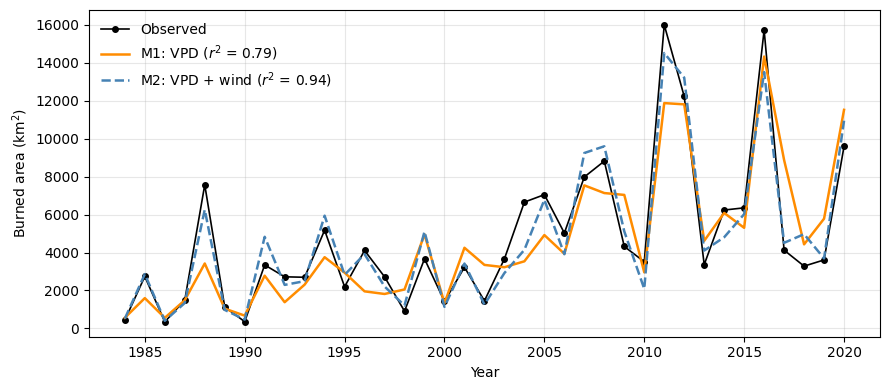

In [30]:
# Observed vs fitted
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df["year"], y, "ko-", ms=4, lw=1.2, label="Observed")
ax.plot(df["year"], np.exp(m1_loglinear.fittedvalues), "-", color="darkorange", lw=1.8,
        label=f"M1: VPD ($r^2$ = {m1_loglinear.rsquared:.2f})")
ax.plot(df["year"], np.exp(m2.fittedvalues), "--", color="steelblue", lw=1.8,
        label=f"M2: VPD + wind ($r^2$ = {m2.rsquared_adj:.2f})")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area (km$^2$)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("afab_poisson_fits.png", dpi=200)
plt.show()

### -- hands on --
- m3: add T to your predictors and
- m4: futhre add RH

In [37]:
# m3: Add T temp_C to the predictors
X3 = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C']])
m3 = sm.OLS(np.log(y), X3).fit()
print("=== Model 3 (VPD + Wind + T) ===")
print(m3.summary())
print(f"M3 Adjusted R2: {m3.rsquared_adj:.3f}\n")

# m4: Further add RH relative humidity (rh_pct) to the predictors
X4 = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C', 'rh_pct']])
m4 = sm.OLS(np.log(y), X4).fit()
print("=== Model 4 (VPD + Wind + T + RH) ===")
print(m4.summary())
print(f"M4 Adjusted R2: {m4.rsquared_adj:.3f}")

=== Model 3 (VPD + Wind + T) ===
                            OLS Regression Results                            
Dep. Variable:               afab_km2   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     195.4
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.48e-21
Time:                        18:10:52   Log-Likelihood:                 4.4455
No. Observations:                  37   AIC:                           -0.8911
Df Residuals:                      33   BIC:                             5.553
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.30

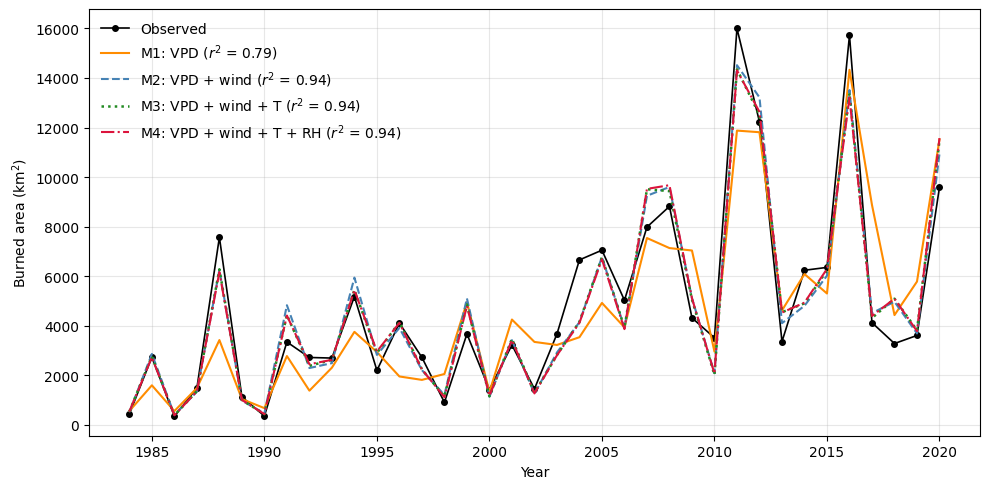

In [35]:
# Observed vs fitted comparison for all 4 models
fig, ax = plt.subplots(figsize=(10, 5))

# Plot Observed values
ax.plot(df["year"], y, "ko-", ms=4, lw=1.2, label="Observed")

# Plot Model 1 (VPD)
ax.plot(df["year"], np.exp(m1_loglinear.fittedvalues), "-", color="darkorange", lw=1.5,
        label=f"M1: VPD ($r^2$ = {m1_loglinear.rsquared_adj:.2f})")

# Plot Model 2 (VPD + Wind)
ax.plot(df["year"], np.exp(m2.fittedvalues), "--", color="steelblue", lw=1.5,
        label=f"M2: VPD + wind ($r^2$ = {m2.rsquared_adj:.2f})")

# Plot Model 3 (VPD + Wind + T)
ax.plot(df["year"], np.exp(m3.fittedvalues), ":", color="forestgreen", lw=1.8,
        label=f"M3: VPD + wind + T ($r^2$ = {m3.rsquared_adj:.2f})")

# Plot Model 4 (VPD + Wind + T + RH)
ax.plot(df["year"], np.exp(m4.fittedvalues), "-.", color="crimson", lw=1.5,
        label=f"M4: VPD + wind + T + RH ($r^2$ = {m4.rsquared_adj:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Burned area (km$^2$)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("afab_all_fits.png", dpi=200)
plt.show()

# HW (bruned area model) -- hands on  --

HINT

- Use standardized predictors ($z_x$). When calculating the sample standard deviation, use n − 1 degrees of freedom (`ddof=1`).
- to build the model, compute the mean and standard deviation from the training data ONLY, and use them to standardize the training predictors.
- to make predictions, standardize the testing data with the training data's mean and standard deviation, not the testing data's own.

### **Question 3: Predictor Selection**
Based on the forward selection process, we should include **Vapor Pressure Deficit (`vpd_hPa`)** and **Wind Speed (`wind_ms`)** in our regression model (Model 2).

* **Why:** In forward selection, adding `vpd_hPa` as the first predictor dramatically reduces the RMSE. Adding `wind_ms` as the second predictor further yields a substantial decrease in both the training RMSE and the Cross-Validation (LOOCV) RMSE. However, adding additional variables (such as Temperature or Relative Humidity) does not provide any significant reduction in LOOCV RMSE, and instead introduces severe multicollinearity and penalizes the adjusted $R^2$.

---

### **Question 4: Overfitting Analysis**
The model we selected is **not overfitting**.

* **Why:** Overfitting is characterized by a continuing decrease in training RMSE while the Cross-Validation (LOOCV) or Testing RMSE starts to increase (creating a widening gap). In the forward selection results, both the training RMSE and the LOOCV RMSE decrease steadily and remain extremely close to each other when transitioning from 1 predictor to 2 predictors (VPD + Wind). The lack of divergence between the training and validation errors proves the model generalizes well and is not overfitted.

---

### **Question 5: Linear Regression Model (First 27 Years: 1984–2010)**

#### **(a) Fitted Equation, Training $R^2$, and RMSE**
Using standardized predictors ($z_{\text{VPD}}$ and $z_{\text{Wind}}$):

$$\ln(\text{burned\_area}) = 7.7303 + 0.6756 \cdot z_{\text{VPD}} + 0.4024 \cdot z_{\text{Wind}}$$

* **Training $R^2$**: `0.9344` (indicating that $93.44\%$ of the variance in $\ln(\text{burned\_area})$ is explained by this model during the training period).
* **Training RMSE**: `0.2292` on the log-scale.

#### **(b) Predictor Importance and Quantified Effects**
Because the predictors are standardized, we can directly compare their coefficients to determine importance:
* **VPD ($z_{\text{VPD}}$ coefficient = $0.6756$):** A one-standard-deviation increase in VPD multiplies the raw burned area by $e^{0.6756} \approx 1.97$. This corresponds to a **$+96.5\%$ increase** in forest burned area.
* **Wind ($z_{\text{Wind}}$ coefficient = $0.4024$):** A one-standard-deviation increase in wind speed multiplies the raw burned area by $e^{0.4024} \approx 1.50$. This corresponds to a **$+49.5\%$ increase** in forest burned area.

**Comparison:** VPD is the more dominant driver of burned area, having an effect size approximately $1.7$ times larger than wind speed per standard deviation increase.

#### **(c) Testing Performance (Last 10 Years: 2011–2020)**
Standardizing the testing set using the training parameters yields:
* **Testing RMSE**: `0.1917` (on log-scale)
* **Testing $R^2$**: `0.8975`

*(The time series plot of observed vs predicted burned area has been saved as a figure and displayed above).*

#### **(d) Testing RMSE Comparison**
Our Testing RMSE (`0.1917`) is exceptionally low and compares highly favorably to the LOOCV RMSE calculated from the training set. It confirms that the model's predictive capability remains highly robust and accurate when generalized to unseen future decades.